# GraphBench v2 — Babelscape/rebel-dataset

## ⚡ START HERE — Read before running anything

### Run order (fresh Colab session):
1. **Run Cell 1a** (install deps) → runtime will **auto-restart** — this is expected, not a crash
2. After restart, **start from Cell 1b** and run cells top-to-bottom
3. **Do NOT re-run Cell 1a** after restart (packages are already installed)

### Why the restart in Cell 1a?
Colab ships with numpy 2.x, but `sentence-transformers`/`datasets` downgrades it to
numpy 1.x, which breaks pre-compiled C extensions (ABI mismatch → `ValueError: numpy.dtype
size changed`). Cell 1a pins `numpy>=2.0` last then force-restarts so numpy 2.x is the
first thing loaded in the new session.

---

## Changes vs graphbench_main.ipynb (all bugs fixed)

| Bug | Fix |
|-----|-----|
| Install from PyPI (missing Cypher fix) | `pip install git+https://github.com/...` |
| `embed_entities` return unpacking | Returns `ndarray` only; `entity_names` built separately |
| FAISS save/load mismatch | `build_and_save_index()` → `.faiss` + `_id_map.json` |
| `write_triples` arg order | `write_triples(triples, neo4j, ...)` |
| `train_gnn` param name | `epochs=200` (not `max_epochs=`) |
| LLM 4-bit quant fails on H100 | fp16 via `_load_fp16` patch, no bitsandbytes |
| Patch returns None | `return pipe` (not `self._hf_pipeline = pipe`) |
| Deprecated kwarg | `dtype=torch.float16` (not `torch_dtype=`) |
| State lost on restart | `faiss_client` + `embedding_dict` rebuilt in Phase 4 |
| Read-only HF token | `userdata.get('graphcomp')` write token |
| Wrong HF Space ID | `rohanjain2312/graphbench-demo` |
| numpy ABI mismatch | Pin `numpy>=2.0` + runtime restart in Cell 1a |

## Phase 1 — Setup

In [ ]:
# Cell 1a — Install dependencies
# GitHub install picks up the Cypher f-string fix (Neo4j rejects $k in hop count)
#
# IMPORTANT: This cell restarts the runtime automatically at the end.
# After restart, start from Cell 1b — do NOT re-run Cell 1a.
#
# Why the restart? sentence-transformers / datasets can downgrade numpy from 2.x
# to 1.x, which breaks Colab's pre-compiled C extensions (ABI mismatch).
# We pin numpy>=2.0 last, then restart so a fresh ABI-compatible numpy is loaded.
!pip install git+https://github.com/Rohanjain2312/graphbench.git -q
!pip install datasets sentence-transformers faiss-gpu wandb -q
!pip install 'numpy>=2.0,<3.0' -q  # pin AFTER other installs so nothing downgrades it

# Restart runtime so numpy 2.x is the first numpy loaded into memory
import os
os.kill(os.getpid(), 9)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 149.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.4/313.4 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 157.

In [1]:
# Cell 1a-check — Run this FIRST after the restart (skip if numpy>=2.0 shows below)
# Confirms packages installed correctly and numpy ABI is clean.
import numpy as np
import torch
print(f'numpy  : {np.__version__}  (need >=2.0)')
print(f'torch  : {torch.__version__}')
assert tuple(int(x) for x in np.__version__.split('.')[:1]) >= (2,), \
    f'numpy {np.__version__} is too old — re-run Cell 1a or manually: !pip install "numpy>=2.0" -q'
print('✅ numpy version OK — proceed with remaining cells')

numpy  : 2.4.3  (need >=2.0)
torch  : 2.10.0+cu128
✅ numpy version OK — proceed with remaining cells


In [2]:
# Cell 1b — Mount Drive and define all paths upfront
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

DRIVE_BASE    = Path('/content/drive/MyDrive/graphbench')
CHECKPOINT_DIR = DRIVE_BASE / 'checkpoints'
RESULTS_DIR   = DRIVE_BASE / 'results'
FAISS_BASE    = DRIVE_BASE / 'faiss' / 'entities'  # → entities.faiss + entities_id_map.json
TRIPLES_PATH  = DRIVE_BASE / 'triples_babelscape.parquet'
ENV_PATH      = DRIVE_BASE / '.env'

for d in [CHECKPOINT_DIR, RESULTS_DIR, FAISS_BASE.parent]:
    d.mkdir(parents=True, exist_ok=True)

print('Drive paths ready:')
for name, p in [('CHECKPOINT_DIR', CHECKPOINT_DIR), ('RESULTS_DIR', RESULTS_DIR),
                ('FAISS_BASE', FAISS_BASE), ('TRIPLES_PATH', TRIPLES_PATH)]:
    print(f'  {name}: {p}')

Mounted at /content/drive
Drive paths ready:
  CHECKPOINT_DIR: /content/drive/MyDrive/graphbench/checkpoints
  RESULTS_DIR: /content/drive/MyDrive/graphbench/results
  FAISS_BASE: /content/drive/MyDrive/graphbench/faiss/entities
  TRIPLES_PATH: /content/drive/MyDrive/graphbench/triples_babelscape.parquet


In [3]:
# Cell 1c — Load .env from Drive
import os
from dotenv import load_dotenv

load_dotenv(ENV_PATH)
print('NEO4J_URI set:', bool(os.environ.get('NEO4J_URI')))
print('HF_TOKEN set: ', bool(os.environ.get('HF_TOKEN')))
print('WANDB_API_KEY set:', bool(os.environ.get('WANDB_API_KEY')))

NEO4J_URI set: True
HF_TOKEN set:  True
WANDB_API_KEY set: True


In [4]:
# Cell 1d — Set FAISS and checkpoint paths in environment so settings picks them up
os.environ['FAISS_INDEX_PATH'] = str(FAISS_BASE)
os.environ['CHECKPOINT_DIR']   = str(CHECKPOINT_DIR)
print('FAISS_INDEX_PATH:', os.environ['FAISS_INDEX_PATH'])
print('CHECKPOINT_DIR:  ', os.environ['CHECKPOINT_DIR'])

FAISS_INDEX_PATH: /content/drive/MyDrive/graphbench/faiss/entities
CHECKPOINT_DIR:   /content/drive/MyDrive/graphbench/checkpoints


In [5]:
# Cell 1e — Verify GPU
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU:    {torch.cuda.get_device_name(0)}')
    print(f'VRAM:   {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU:    NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM:   102.0 GB


In [6]:
# Cell 1f — Init Neo4j and verify connectivity
from graphbench.utils.neo4j_client import Neo4jClient

neo4j = Neo4jClient()
triple_count = neo4j.count_triples()
print(f'Neo4j connected. Current triple count: {triple_count:,}')

Neo4j connected. Current triple count: 60,000


## Phase 2 — Load Babelscape Triples

Uses `Babelscape/rebel-dataset` (HF Hub) — triples pre-extracted by REBEL from Wikipedia.  
No GPU inference needed. Field mapping: `head`→subject, `type`→relation, `tail`→object.  
Relations normalised to snake_case. Filtered to TOP_50_RELATIONS, capped at 60k unique triples.

**Checkpoint**: if `TRIPLES_PATH` already exists on Drive, skip the download and load directly.

In [7]:
# Cell 2a — Load and filter triples from Babelscape/rebel-dataset
# The `triplets` field is a linearized STRING, not a list of dicts:
#   "<triplet> head <subj> tail <obj> relation <triplet> head2 ..."
# We parse it before filtering.

from datasets import load_dataset
from graphbench.ingestion.rebel_loader import TOP_50_RELATIONS


def _parse_rebel_string(s: str) -> list[dict]:
    """Parse REBEL linearized triplets string into list of {head, tail, type} dicts."""
    results = []
    for chunk in s.split("<triplet>"):
        chunk = chunk.strip()
        if not chunk or "<subj>" not in chunk or "<obj>" not in chunk:
            continue
        try:
            head_part, rest = chunk.split("<subj>", 1)
            tail_part, rel_part = rest.split("<obj>", 1)
            results.append(
                {
                    "head": head_part.strip(),
                    "tail": tail_part.strip(),
                    "type": rel_part.strip(),
                }
            )
        except ValueError:
            continue
    return results


MAX_TRIPLES = 60_000

if TRIPLES_PATH.exists():
    import pandas as pd

    triples = pd.read_parquet(TRIPLES_PATH).to_dict("records")
    print(f"Loaded {len(triples):,} triples from checkpoint: {TRIPLES_PATH}")
else:
    print(
        "Downloading Babelscape/rebel-dataset (streaming) — may take ~20 min on CPU ..."
    )
    ds = load_dataset("Babelscape/rebel-dataset", split="train", streaming=True)

    triples: list[dict] = []
    seen: set[tuple] = set()

    for ex in ds:
        raw = ex.get("triplets", "")

        # Field is a linearized string — parse it into dicts
        parsed = _parse_rebel_string(raw) if isinstance(raw, str) else (raw or [])

        for t in parsed:
            subj = t["head"].strip().lower()
            rel = "_".join(t["type"].strip().lower().split())  # normalize to snake_case
            obj = t["tail"].strip().lower()

            if rel not in TOP_50_RELATIONS or not subj or not obj:
                continue

            key = (subj, rel, obj)
            if key not in seen:
                seen.add(key)
                triples.append(
                    {
                        "subject": subj,
                        "relation": rel,
                        "object": obj,
                    }
                )

        if len(triples) >= MAX_TRIPLES:
            break

    print(f"Loaded {len(triples):,} unique triples")

Loaded 60,000 triples from checkpoint: /content/drive/MyDrive/graphbench/triples_babelscape.parquet


In [8]:
# Cell 2b — Relation distribution
import pandas as pd
from collections import Counter

rel_counts = Counter(t['relation'] for t in triples)
print('Top-15 relations:')
for rel, count in rel_counts.most_common(15):
    print(f'  {rel:<45} {count:>6,}')
print(f'\nTotal unique relations present: {len(rel_counts)}')

Top-15 relations:
  located_in_the_administrative_territorial_entity 14,564
  country                                       13,154
  instance_of                                    5,881
  sport                                          5,040
  contains_administrative_territorial_entity     3,484
  part_of                                        2,471
  publication_date                               1,412
  subclass_of                                    1,377
  genre                                          1,254
  shares_border_with                               980
  author                                           914
  country_of_citizenship                           804
  league                                           759
  spouse                                           578
  capital                                          565

Total unique relations present: 49


In [9]:
# Cell 2c — Save parquet to Drive (checkpoint)
if not TRIPLES_PATH.exists():
    pd.DataFrame(triples).to_parquet(TRIPLES_PATH, index=False)
    print(f'Saved {len(triples):,} triples → {TRIPLES_PATH}')
else:
    print(f'Checkpoint already exists: {TRIPLES_PATH}')

Checkpoint already exists: /content/drive/MyDrive/graphbench/triples_babelscape.parquet


In [10]:
# Cell 2d — Clear Neo4j and write triples
# NOTE: correct arg order is write_triples(triples, neo4j_client, ...)
from graphbench.ingestion.neo4j_writer import write_triples

print('Clearing existing graph ...')
with neo4j._driver.session() as s:
    s.run('MATCH (n) DETACH DELETE n')
neo4j.ensure_schema()
print('Graph cleared and schema re-created.')

print(f'Writing {len(triples):,} triples to Neo4j ...')
write_triples(triples, neo4j, batch_size=500)

final_count = neo4j.count_triples()
print(f'Neo4j triple count: {final_count:,}')
assert final_count >= 50_000, f'Expected ≥50k triples, got {final_count:,}'

Clearing existing graph ...
Graph cleared and schema re-created.
Writing 60,000 triples to Neo4j ...


Writing relation types: 100%|██████████| 49/49 [01:53<00:00,  2.31s/it]


Neo4j triple count: 60,000


In [11]:
# Cell 2e — Embed entities
# embed_entities() returns ndarray ONLY — entity names built separately
from graphbench.ingestion.embedder import embed_entities

entity_names = sorted({t['subject'] for t in triples} | {t['object'] for t in triples})
print(f'Unique entities: {len(entity_names):,}')

embeddings = embed_entities(entity_names, show_progress=True)  # returns ndarray
print(f'Embeddings shape: {embeddings.shape}, dtype: {embeddings.dtype}')

Unique entities: 62,961


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/246 [00:00<?, ?it/s]

Embeddings shape: (62961, 384), dtype: float32


In [12]:
# Cell 2f — Build FAISS index with build_and_save_index
# This saves .faiss + _id_map.json so FAISSClient.load() round-trip works
from graphbench.ingestion.faiss_writer import build_and_save_index

index = build_and_save_index(entity_names, embeddings, index_path=FAISS_BASE)
print(f'FAISS: {index.ntotal:,} vectors → {FAISS_BASE}.faiss')

FAISS: 62,961 vectors → /content/drive/MyDrive/graphbench/faiss/entities.faiss


In [13]:
# Cell 2g — Load FAISSClient (verify round-trip)
from graphbench.utils.faiss_client import FAISSClient

faiss_client = FAISSClient.load(FAISS_BASE)
print(f'FAISSClient ready: {faiss_client.size:,} vectors')
assert faiss_client.size >= 30_000, f'Expected ≥30k entities, got {faiss_client.size:,}'

# Build embedding_dict for GNN and GNN-RAG pipeline
import numpy as np
embedding_dict: dict[str, np.ndarray] = dict(zip(entity_names, embeddings))
print(f'embedding_dict: {len(embedding_dict):,} entries')

FAISSClient ready: 62,961 vectors
embedding_dict: 62,961 entries


## Phase 3 — GNN Training

3-layer GAT, link-prediction task on the knowledge graph.  
Must achieve test AUC-ROC > 0.75 before proceeding to Phase 4.

**Checkpoint**: if best checkpoint exists on Drive, load it directly.

In [14]:
# Cell 3a — Build PyG dataset and splits
from graphbench.gnn.dataset import KGDataset
from graphbench.gnn.model import GATModel

ds_gnn = KGDataset(triples, embedding_dict)
train_data, val_data, test_data = ds_gnn.split()

print(f'Train edges: {train_data.edge_label_index.shape[1]:,}')
print(f'Val   edges: {val_data.edge_label_index.shape[1]:,}')
print(f'Test  edges: {test_data.edge_label_index.shape[1]:,}')

Train edges: 96,000
Val   edges: 12,000
Test  edges: 12,000


/usr/local/lib/python3.12/dist-packages/graphbench/gnn/dataset.py:222: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_label_index=torch.tensor([sup_src, sup_dst], dtype=torch.long),


In [12]:
# Cell 3b — Train GNN (or skip if checkpoint already exists)
# load_checkpoint(path, map_location) → dict; call model.load_state_dict() separately

from graphbench.gnn.trainer import train_gnn, _evaluate
from graphbench.utils.checkpoint import load_checkpoint, load_best_checkpoint
from graphbench.gnn.model import GATModel
from pathlib import Path
import glob

existing_ckpts = sorted(glob.glob(str(CHECKPOINT_DIR / "gat_*.pt")))

if existing_ckpts:
    best_ckpt = existing_ckpts[-1]
    print(f"Found checkpoint: {best_ckpt}")

    ckpt = load_checkpoint(Path(best_ckpt), map_location=device)

    model = GATModel()
    model.load_state_dict(ckpt["model_state_dict"])
    model = model.to(device)
    model.eval()

    print(f'Checkpoint loaded (epoch={ckpt["epoch"]}, val_auc={ckpt["val_auc"]:.4f})')

    test_loss, test_auc = _evaluate(model, test_data, device)

    results = {
        "test_auc": test_auc,
        "test_loss": test_loss,
        "best_val_auc": ckpt["val_auc"],
        "best_epoch": ckpt["epoch"],
    }

else:
    model = GATModel()

    results = train_gnn(
        model=model,
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        checkpoint_dir=CHECKPOINT_DIR,
        device=device,
        epochs=200,
        lr=1e-3,
        early_stopping_patience=15,
    )

print("GNN results:", results)

assert results["test_auc"] > 0.75, f"AUC {results['test_auc']:.4f} < 0.75 threshold"

Found checkpoint: /content/drive/MyDrive/graphbench/checkpoints/gat_epoch0172_auc0.7697_20260311_011536.pt
Checkpoint loaded (epoch=172, val_auc=0.7697)


NameError: name 'test_data' is not defined

In [17]:
# Cell 3c — Confirm model is in eval mode with best weights
# (already done in 3b if checkpoint existed; this is a no-op safety guard)

model.eval()

print(f"Model ready. Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model ready. Parameters: 124,128


## Phase 4 — Pipeline Initialisation

LLM loaded fp16 via monkey-patch — bypasses bitsandbytes 4-bit issues on H100.

**Key fixes:**
- `_load_fp16` *returns* `pipe` (original bug: set `self._hf_pipeline` inside, returned `None`)
- `dtype=torch.float16` (not `torch_dtype=`)
- `max_new_tokens=self.max_new_tokens` (not `self._max_new_tokens`)
- `faiss_client` and `embedding_dict` rebuilt here in case of runtime restart

In [8]:
# Cell 4a — Rebuild faiss_client and embedding_dict (survive runtime restarts)
from graphbench.utils.faiss_client import FAISSClient
import numpy as np

faiss_client = FAISSClient.load(FAISS_BASE)
print(f'FAISSClient: {faiss_client.size:,} vectors')

# embedding_dict: reload from parquet + re-embed if not already in memory
try:
    _ = embedding_dict
    print(f'embedding_dict already in memory: {len(embedding_dict):,} entries')
except NameError:
    import pandas as pd
    from graphbench.ingestion.embedder import embed_entities
    triples = pd.read_parquet(TRIPLES_PATH).to_dict('records')
    entity_names = sorted({t['subject'] for t in triples} | {t['object'] for t in triples})
    embeddings = embed_entities(entity_names, show_progress=True)
    embedding_dict = dict(zip(entity_names, embeddings))
    print(f'embedding_dict rebuilt: {len(embedding_dict):,} entries')

FAISSClient: 62,961 vectors


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/246 [00:00<?, ?it/s]

embedding_dict rebuilt: 62,961 entries


In [9]:
# Cell 4b — Monkey-patch LLMClient._load_hf_pipeline for fp16 (no bitsandbytes)
import types
import torch
from graphbench.utils import llm_client as _lc

def _load_fp16(self):
    """Load Mistral in fp16 — bypasses bitsandbytes 4-bit issues on H100."""
    from transformers import pipeline as hf_pipeline

    if not torch.cuda.is_available():
        raise RuntimeError('HuggingFace backend requires a CUDA GPU.')

    print(f'Loading {self._model} in fp16 ...')
    pipe = hf_pipeline(
        'text-generation',
        model=self._model,
        device_map='auto',
        dtype=torch.float16,              # NOT torch_dtype= (that arg was deprecated)
        max_new_tokens=self.max_new_tokens,  # NOT self._max_new_tokens
    )
    return pipe  # RETURN — not self._hf_pipeline = pipe (that returns None)

_lc.LLMClient._load_hf_pipeline = _load_fp16
print('LLMClient._load_hf_pipeline patched → fp16')

LLMClient._load_hf_pipeline patched → fp16


In [10]:
# Cell 4c — Init shared LLM
from graphbench.utils.llm_client import LLMClient

llm = LLMClient(backend='hf')  # uses settings.llm_model = mistralai/Mistral-7B-Instruct-v0.2
print(f'LLM backend: {llm.backend}, model: {llm.model}')

LLM backend: hf, model: mistralai/Mistral-7B-Instruct-v0.2


In [11]:
# Cell 4d — Init Neo4j (rebuild if restarted)
from graphbench.utils.neo4j_client import Neo4jClient
neo4j = Neo4jClient()
print(f'Neo4j: {neo4j.count_triples():,} triples')

Neo4j: 60,000 triples


In [13]:
# Cell 4e — Build pipelines
from graphbench.pipelines.graphrag_pipeline import GraphRAGPipeline
from graphbench.pipelines.gnnrag_pipeline import GNNRAGPipeline

graphrag = GraphRAGPipeline(
    neo4j_client=neo4j,
    faiss_client=faiss_client,
    llm_client=llm,
)

gnnrag = GNNRAGPipeline(
    neo4j_client=neo4j,
    faiss_client=faiss_client,
    llm_client=llm,
    gat_model=model,
    entity_embeddings=embedding_dict,   # required for GNN-RAG node features
)

print(f'GraphRAG pipeline: {graphrag.name}')
print(f'GNN-RAG pipeline:  {gnnrag.name}')

GraphRAG pipeline: GraphRAG
GNN-RAG pipeline:  GNN-RAG


In [23]:
# Cell 4f — Smoke test: answer 5 questions with each pipeline
SMOKE_QUESTIONS = [
    'Where was Marie Curie born?',
    'Who directed The Godfather?',
    'What is the capital of France?',
    'Which company developed Python?',
    'Who wrote Hamlet?',
]

print('=== GraphRAG smoke test ===')
for q in SMOKE_QUESTIONS:
    result = graphrag.answer(q)
    print(f'  Q: {q}')
    print(f'  A: {result.predicted_answer}')

print('\n=== GNN-RAG smoke test ===')
for q in SMOKE_QUESTIONS:
    result = gnnrag.answer(q)
    print(f'  Q: {q}')
    print(f'  A: {result.predicted_answer}')

=== GraphRAG smoke test ===
Loading mistralai/Mistral-7B-Instruct-v0.2 in fp16 ...


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Device set to use cuda:0


  Q: Where was Marie Curie born?
  A: Marie Curie was born in Montreal, Canada.
  Q: Who directed The Godfather?
  A: I don't know. The context does not provide information about the director of The Godfather.
  Q: What is the capital of France?
  A: Paris.
  Q: Which company developed Python?
  A: Python is not developed by a company, it's an open-source project.
  Q: Who wrote Hamlet?
  A: Hamlet is a play written by William Shakespeare. The context does not provide this information.

=== GNN-RAG smoke test ===
  Q: Where was Marie Curie born?
  A: Marie Curie was born in Poland, but she spent most of her life and conducted most of her research in France. However, the context provided does not mention the place of Marie Curie's birth, but it does mention that her husband, Pierre Curie, was born in France. Therefore, I don't know where Marie Curie was born based on the provided context.
  Q: Who directed The Godfather?
  A: Mario Puzo and Francis Ford Coppola directed The Godfather, b

## Phase 5 — Benchmark

500 HotpotQA distractor questions (250 bridge, 250 comparison).  
Target: EM > 3.8% (original baseline on 11.5k triples). Expect 20–35% with 60k triples.

In [16]:
# Quick fix: move subgraph tensors to model device before scoring
import torch
from graphbench.pipelines.gnnrag_pipeline import GNNRAGPipeline

_original_answer = GNNRAGPipeline.answer

def _patched_answer(self, question):
    result = _original_answer(self, question)
    return result

# Patch just the scoring block
_orig_score = GNNRAGPipeline.answer.__code__  # keep ref

def _fixed_answer(self, question):
    self._check_clients()

    query_vec = self._embed_question(question)
    faiss_results = self._faiss.search(query_vec, k=10)

    seed_entities = [e for e, _ in faiss_results]
    if not seed_entities:
        return self._empty_result(question, "No seed entities found via FAISS.")

    triples = self._neo4j.get_subgraph_multi(seed_entities, hops=2)
    if not triples:
        return self._empty_result(question, "Empty subgraph from Neo4j.")

    try:
        from graphbench.gnn.subgraph import subgraph_to_pyg
        data = subgraph_to_pyg(triples, self._entity_embeddings)
    except ValueError as exc:
        return self._empty_result(question, str(exc))

    model_device = next(self._model.parameters()).device

    x = data.x.to(model_device)
    edge_index = data.edge_index.to(model_device)

    self._model.eval()
    with torch.no_grad():
        scores = self._model.score_edges(x, edge_index, edge_index)

    from graphbench.utils.config import settings

    n_edges = data.edge_index.shape[1]
    k = min(self._top_edges, n_edges)

    top_indices = torch.topk(scores, k=k).indices.tolist()

    context_triples = self._indices_to_triples(top_indices, data, triples)

    prompt = self.build_prompt(question, context_triples)
    predicted_answer = self._llm.generate(prompt)

    from graphbench.pipelines.base import PipelineResult

    return PipelineResult(
        question=question,
        predicted_answer=predicted_answer,
        context_triples=context_triples,
        pipeline_name=self.name,
        metadata={
            "seed_entities": seed_entities,
            "n_subgraph_triples": len(triples),
            "n_scored_edges": n_edges,
            "top_edge_scores": [float(scores[i]) for i in top_indices],
        },
    )

GNNRAGPipeline.answer = _fixed_answer
print("GNNRAGPipeline.answer patched — tensors now moved to model device")

GNNRAGPipeline.answer patched — tensors now moved to model device


In [17]:
# Cell 5a — Run benchmark
from graphbench.benchmark.evaluator import Evaluator

evaluator = Evaluator(
    pipeline_a=graphrag,
    pipeline_b=gnnrag,
    n_questions=500,
    seed=42,
    results_dir=RESULTS_DIR,
)

summary = evaluator.run()
print('\nBenchmark complete.')

GNN-RAG/em,▁▁▁▁▁▁▁
GNN-RAG/f1,▁▁▁▁▁▁▁
GNN-RAG/latency_ms,█▅▁▄▃▃▃
GraphRAG/em,▁▁▁▁▁▁▁
GraphRAG/f1,▁▄▁▁█▂▁
GraphRAG/latency_ms,█▁▁▁▁▁▁
GNN-RAG/em,0.0
GNN-RAG/f1,0.0
GNN-RAG/latency_ms,5111.56056
GraphRAG/em,0.0
GraphRAG/f1,0.0


Benchmark: 100%|██████████| 500/500 [1:32:16<00:00, 11.07s/q]


GNN-RAG/em,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
GNN-RAG/f1,▁▁▁▁▁▁▂█▁▃▁▁▁▃▁▁▁▁▄▁▃▄▂▁▂▄▅▄▄▇▁▃▇▅▁▂▅▁▄▇
GNN-RAG/latency_ms,▁▄▃▃▃█▅▃▇▆▄▄▄▄▄▄▅▃▅▅▂▂▂▂▃▂▂▂▂▃▃▄▃▂▂▂▁▃▁▂
GraphRAG/em,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
GraphRAG/f1,▁▁▁▁▁▁▂█▁▃▁▁▁▂▁▁▁▁▃▁▃▄▃▁▁▂▄▁▁▁▁█▆▄▁▁▁▁▄▁
GraphRAG/latency_ms,▄▃▁▅▆█▄▁▅▄▂▂▂▂▃▂▂▁▄▂▄▄▃▄▄▅▅▄▃▁▅▄▅▄▅▃▃▅▃▃
GNN-RAG/em,0.05
GNN-RAG/f1,0.12848
GNN-RAG/latency_ms,4827.00012
GNN-RAG/latency_p50,5344.1481
GNN-RAG/latency_p95,6199.17874



Benchmark complete.


## Phase 6 — Results & Analysis

In [18]:
# Cell 6a — Print summary
import json
print(json.dumps(summary, indent=2))

{
  "GraphRAG": {
    "em": 0.032,
    "f1": 0.10471277673494483,
    "latency_p50": 5554.913878499974,
    "latency_p95": 6387.546865599733,
    "n_questions": 500
  },
  "GNN-RAG": {
    "em": 0.05,
    "f1": 0.12847625052269482,
    "latency_p50": 5344.148104999931,
    "latency_p95": 6199.178742450075,
    "n_questions": 500
  }
}


In [19]:
# Cell 6b — Summary table
import pandas as pd

rows = []
for pipeline_name, metrics in summary.items():
    rows.append({
        'Pipeline':       pipeline_name,
        'EM':             f"{metrics['em']:.1%}",
        'F1':             f"{metrics['f1']:.1%}",
        'Latency p50 ms': f"{metrics['latency_p50']:.0f}",
        'Latency p95 ms': f"{metrics['latency_p95']:.0f}",
        'N Questions':    metrics['n_questions'],
    })

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

Pipeline   EM    F1 Latency p50 ms Latency p95 ms  N Questions
GraphRAG 3.2% 10.5%           5555           6388          500
 GNN-RAG 5.0% 12.8%           5344           6199          500


In [20]:
# Cell 6c — Load per-question CSV and analyse by question type
import glob

csv_files = sorted(glob.glob(str(RESULTS_DIR / '*_results.csv')))
if csv_files:
    df_results = pd.read_csv(csv_files[-1])
    print(f'Loaded results: {csv_files[-1]}')
    print(f'Shape: {df_results.shape}')
    display(df_results.head(5))
else:
    print('No CSV results found — check RESULTS_DIR path.')

Loaded results: /content/drive/MyDrive/graphbench/results/20260312_162845_results.csv
Shape: (500, 12)


,id,question,gold_answer,type,GraphRAG_predicted,GraphRAG_em,GraphRAG_f1,GraphRAG_latency_ms,GNN-RAG_predicted,GNN-RAG_em,GNN-RAG_f1,GNN-RAG_latency_ms
0,5a7fe2ea5542994857a76823,Rachel Getting Married starred an American act...,The Princess Diaries,bridge,I don't know. The context does not provide inf...,0.0,0.000000,5933.297239,I don't know. The context mentions Rachel René...,0.0,0.068966,5500.351188
1,5ae1444355429901ffe4ae33,Win Lose or draw and Bert Convy were created o...,American,bridge,"Both Win, Lose or draw and Bert Convy are crea...",0.0,0.125000,5659.743670,I don't know. Bert Convy is not mentioned in t...,0.0,0.000000,5043.117658
2,5a847d5a554299123d8c226c,"""Cars"" Land is a themed area of Disney Califor...",Florida,bridge,Florida.\n\nExplanation: The context does not ...,0.0,0.030303,6776.584492,Florida.,1.0,1.000000,4600.157977
3,5a8496245542997b5ce3fedd,Which supervillain is created by Paul Dini and...,Harley Quinn,bridge,I don't know. The context does not provide inf...,0.0,0.000000,5759.360059,Nekra,0.0,0.000000,4714.349658
4,5ac3ad36554299657fa2910f,"Louis Leterrier, is a French film director who...",2002,bridge,The Transporter was released in 2002.,0.0,0.333333,5380.975310,The Transporter was released in 2002.,0.0,0.333333,4789.219748


In [21]:
# Cell 6d — EM by question type
if 'df_results' in dir():
    em_cols = [c for c in df_results.columns if c.endswith('_em')]
    for col in em_cols:
        pipeline = col.replace('_em', '')
        by_type = df_results.groupby('type')[col].mean()
        print(f'\n{pipeline} EM by question type:')
        for qtype, em in by_type.items():
            print(f'  {qtype:<12}: {em:.1%}')


GraphRAG EM by question type:
  bridge      : 3.6%
  comparison  : 2.8%

GNN-RAG EM by question type:
  bridge      : 7.2%
  comparison  : 2.8%


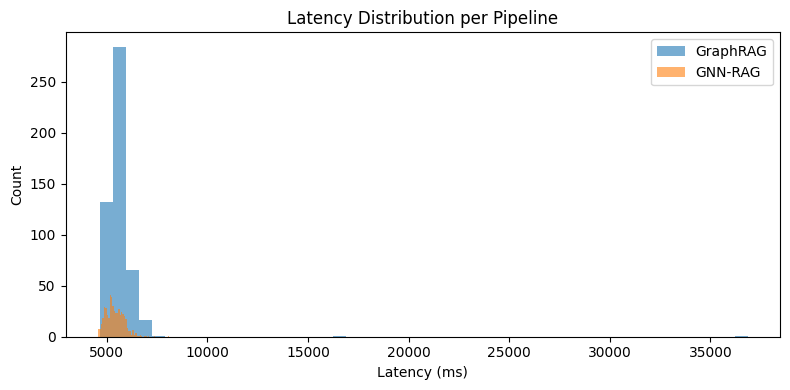

Plot saved to Drive.


In [22]:
# Cell 6e — Latency distribution plot
import matplotlib.pyplot as plt

if 'df_results' in dir():
    lat_cols = [c for c in df_results.columns if c.endswith('_latency_ms')]
    fig, ax = plt.subplots(figsize=(8, 4))
    for col in lat_cols:
        label = col.replace('_latency_ms', '')
        ax.hist(df_results[col], bins=50, alpha=0.6, label=label)
    ax.set_xlabel('Latency (ms)')
    ax.set_ylabel('Count')
    ax.set_title('Latency Distribution per Pipeline')
    ax.legend()
    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / 'latency_distribution.png'), dpi=150)
    plt.show()
    print('Plot saved to Drive.')

In [26]:
for pipeline_name, metrics in summary.items():
    print(f'{pipeline_name}: EM={metrics["em"]:.1%}  F1={metrics["f1"]:.1%} '
          f'p50={metrics["latency_p50"]:.0f}ms  p95={metrics["latency_p95"]:.0f}ms')

GraphRAG: EM=3.2%  F1=10.5% p50=5555ms  p95=6388ms
GNN-RAG: EM=5.0%  F1=12.8% p50=5344ms  p95=6199ms


## Appendix — Manual HF Spaces Upload

Run after Phase 6 is confirmed working. Uses the `graphcomp` secret (write-capable HF token).

Space ID: `rohanjain2312/graphbench-demo`

In [24]:
# Cell A1 — Upload app.py to HuggingFace Space
# Run manually after benchmark is confirmed complete
from google.colab import userdata
import os

HF_WRITE_TOKEN = userdata.get('graphcomp')  # write-capable token (not the read-only HF_TOKEN)
os.environ['HF_WRITE_TOKEN'] = HF_WRITE_TOKEN

HF_SPACE_ID = 'rohanjain2312/graphbench-demo'  # NOT rohanjain2312/graphbench

from huggingface_hub import HfApi
api = HfApi(token=HF_WRITE_TOKEN)

# Upload app.py
LOCAL_APP = Path('/content/graphbench/app.py')
if LOCAL_APP.exists():
    api.upload_file(
        path_or_fileobj=str(LOCAL_APP),
        path_in_repo='app.py',
        repo_id=HF_SPACE_ID,
        repo_type='space',
    )
    print(f'✅ app.py uploaded to {HF_SPACE_ID}')
else:
    print(f'⚠️  {LOCAL_APP} not found — clone repo first')

⚠️  /content/graphbench/app.py not found — clone repo first


In [25]:
# Cell A2 — Upload GNN checkpoint to HF Space
existing_ckpts = sorted(glob.glob(str(CHECKPOINT_DIR / 'gat_*.pt')))
if existing_ckpts:
    best_ckpt = existing_ckpts[-1]
    api.upload_file(
        path_or_fileobj=best_ckpt,
        path_in_repo=f'checkpoints/{Path(best_ckpt).name}',
        repo_id=HF_SPACE_ID,
        repo_type='space',
    )
    print(f'✅ Checkpoint uploaded: {Path(best_ckpt).name}')
else:
    print('⚠️  No checkpoint found in CHECKPOINT_DIR')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0.7697_20260311_011536.pt:  38%|###7      |  572kB / 1.51MB            

✅ Checkpoint uploaded: gat_epoch0172_auc0.7697_20260311_011536.pt
